In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from tqdm import tqdm

# Import your custom OOP unconstrainers
from models import NaiveUnconstrainer, EMUnconstrainer, MARSSEMUnconstrainer, EMPriceUnconstrainer, MARSSXPriceUnconstrainer

# Plotting aesthetics suited for an academic paper
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 7)
plt.rcParams['font.size'] = 12

In [2]:
# 1. Load Data
data_path = '../data/air_cargo_10yr_dataset.csv'
df = pd.read_csv(data_path)
df['Date'] = pd.to_datetime(df['Date'])

# 2. Isolate Route and sort chronologically (CRITICAL for rolling windows)
sample_df = df[
    (df['Origin'] == 'PVG') & 
    (df['Destination'] == 'LAX')
].copy()

sample_df = sample_df.sort_values('Date').reset_index(drop=True)

# 3. Handle fuzzy capacity (if a flight wasn't perfectly 100k, we use its observed weight as the wall)
# If it wasn't censored, the capacity wall doesn't matter, we just pass 100k as a placeholder.
sample_df['Fuzzy_Capacity'] = np.where(
    sample_df['Is_Censored'], 
    sample_df['Final_Constrained_Bookings'], 
    100000
)

print(f"Total flights for PVG->LAX: {len(sample_df)}")

Total flights for PVG->LAX: 3653


In [3]:
lookback = 365
total_days = len(sample_df)

# Initialize ALL result columns with NaNs to prevent pandas fragmentation warnings
sample_df['Naive_Est'] = np.nan
sample_df['EM_Est'] = np.nan
sample_df['MARSS_Est'] = np.nan
sample_df['EMXPrice_Est'] = np.nan
sample_df['MARSSXPrice_Est'] = np.nan

# Initialize the models
models = {
    'Naive': (NaiveUnconstrainer(), 'Naive_Est'),
    'EM': (EMUnconstrainer(), 'EM_Est'),
    'MARSS': (MARSSEMUnconstrainer(), 'MARSS_Est'),
    'EM-X Price': (EMPriceUnconstrainer(), 'EMXPrice_Est'),
    'MARSS-X Price': (MARSSXPriceUnconstrainer(), 'MARSSXPrice_Est')
}

print(f"Starting 1-Year Rolling Evaluation (Skipping first {lookback} days as burn-in)...")

# Convert columns to numpy arrays for faster slicing
# FIX: Extract Price_Index from sample_df, NOT the global df
obs_arr = sample_df['Final_Constrained_Bookings'].values
cens_arr = sample_df['Is_Censored'].values
cap_arr = sample_df['Fuzzy_Capacity'].values
price_arr = sample_df['Final_Price_per_kg'].values 

for t in tqdm(range(lookback+365*4, total_days)):
    # Print progress every year
    if t % 365 == 0:
        print(f"Processing Year {(t // 365) + 1}...")
        
    # SLICE THE PAST + TODAY
    win_start = t - lookback + 1
    win_end = t + 1
    
    win_obs = obs_arr[win_start:win_end]
    win_cens = cens_arr[win_start:win_end]
    win_cap = cap_arr[win_start:win_end]
    win_price = price_arr[win_start:win_end] 
    
    # Run each model on the isolated window
    for name, (model, col_name) in models.items():
        # If today is NOT censored, latent demand is simply the observed bookings.
        if not win_cens[-1]:
            sample_df.loc[t, col_name] = win_obs[-1]
            continue
            
        # FIX: Conditionally pass the price_index argument only to models that need it
        if 'Price' in name:
            imputed_window = model.fit(
                observed_bookings=win_obs,
                is_censored=win_cens,
                capacity=win_cap,
                price_per_kg=win_price,
                max_iter=50
            )
        else:
            imputed_window = model.fit(
                observed_bookings=win_obs,
                is_censored=win_cens,
                capacity=win_cap,
                max_iter=50
            )
        
        # Save the very last value in the array (Today's estimate)
        sample_df.loc[t, col_name] = imputed_window[-1]

print("Rolling evaluation complete!")

Starting 1-Year Rolling Evaluation (Skipping first 365 days as burn-in)...


  8%|▊         | 146/1828 [00:00<00:01, 1457.75it/s]

Processing Year 6...


 19%|█▉        | 351/1828 [01:05<09:24,  2.62it/s]  

Processing Year 7...


...

Processing Year 10...


100%|█████████▉| 1822/1828 [10:05<00:06,  1.08s/it]

Processing Year 11...


100%|██████████| 1828/1828 [10:12<00:00,  2.98it/s]

Rolling evaluation complete!


In [4]:
# Filter down to the evaluation period (where we actually made predictions)
eval_df = sample_df.iloc[lookback+365*4:].copy()

true_demand = eval_df['Final_True_Demand'].values

print("--- Out-of-Sample Performance Metrics ---")
for name, (_, col_name) in models.items():
    estimated = eval_df[col_name].values
    
    # Calculate RMSE and MAE
    rmse = np.sqrt(np.mean((true_demand - estimated) ** 2))
    mae = np.mean(np.abs(true_demand - estimated))
    
    print(f"{name.ljust(10)} | RMSE: {rmse:,.0f} | MAE: {mae:,.0f}")

--- Out-of-Sample Performance Metrics ---
Naive      | RMSE: 5,683 | MAE: 1,376
EM         | RMSE: 3,729 | MAE: 873
MARSS      | RMSE: 3,388 | MAE: 840
EM-X Price | RMSE: 3,696 | MAE: 863
MARSS-X Price | RMSE: 3,355 | MAE: 819


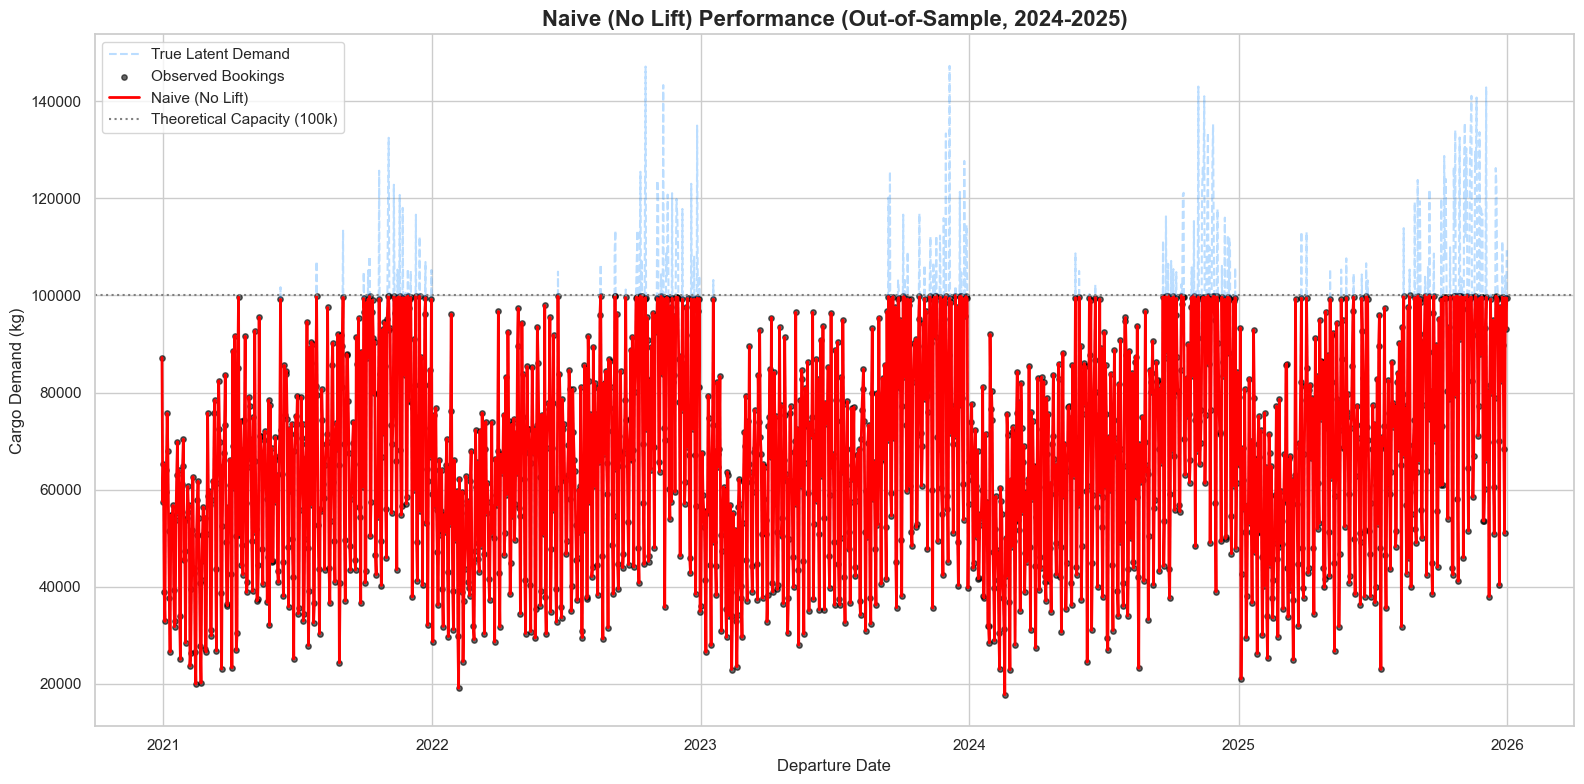

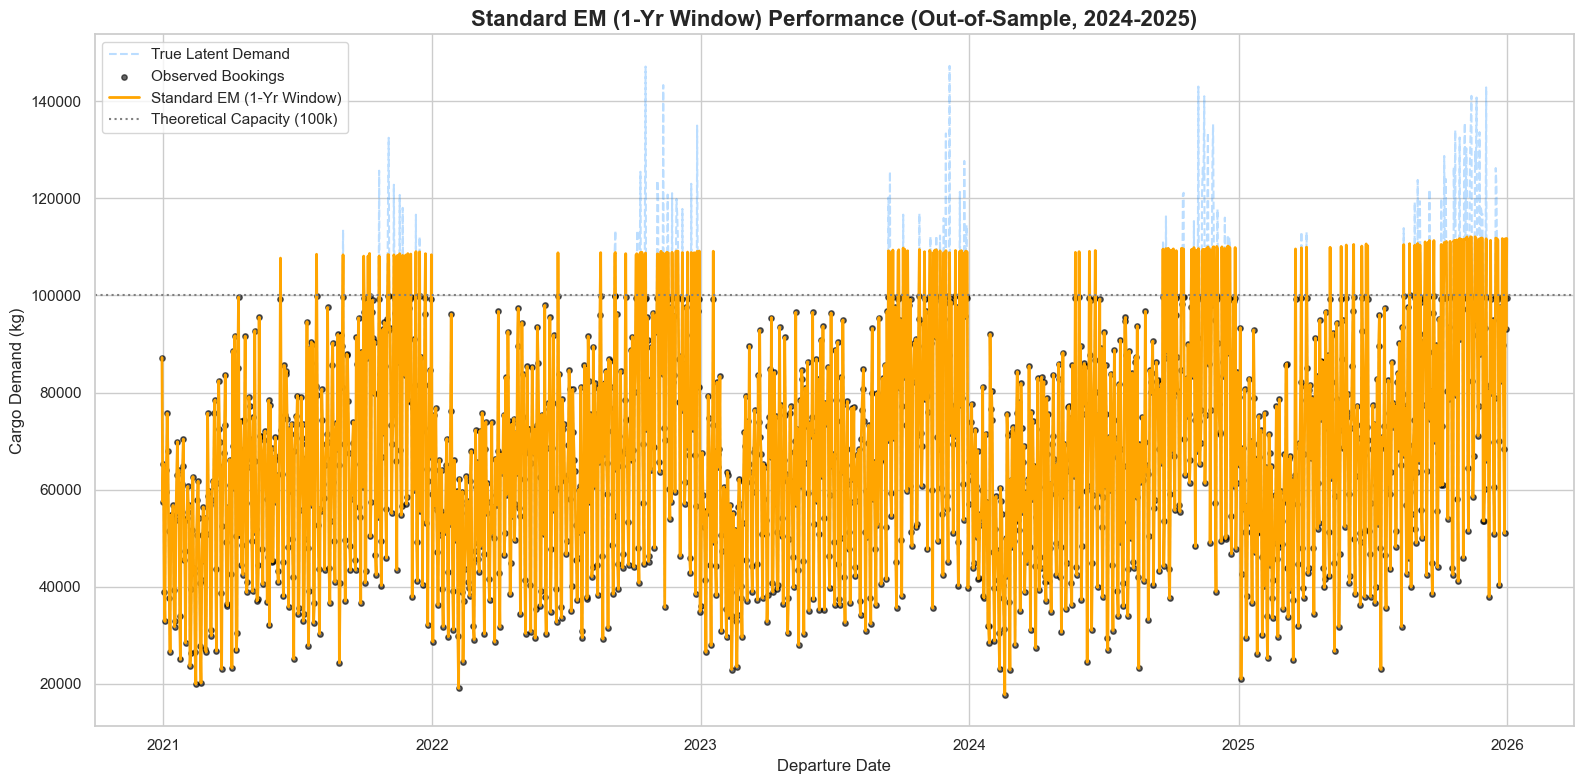

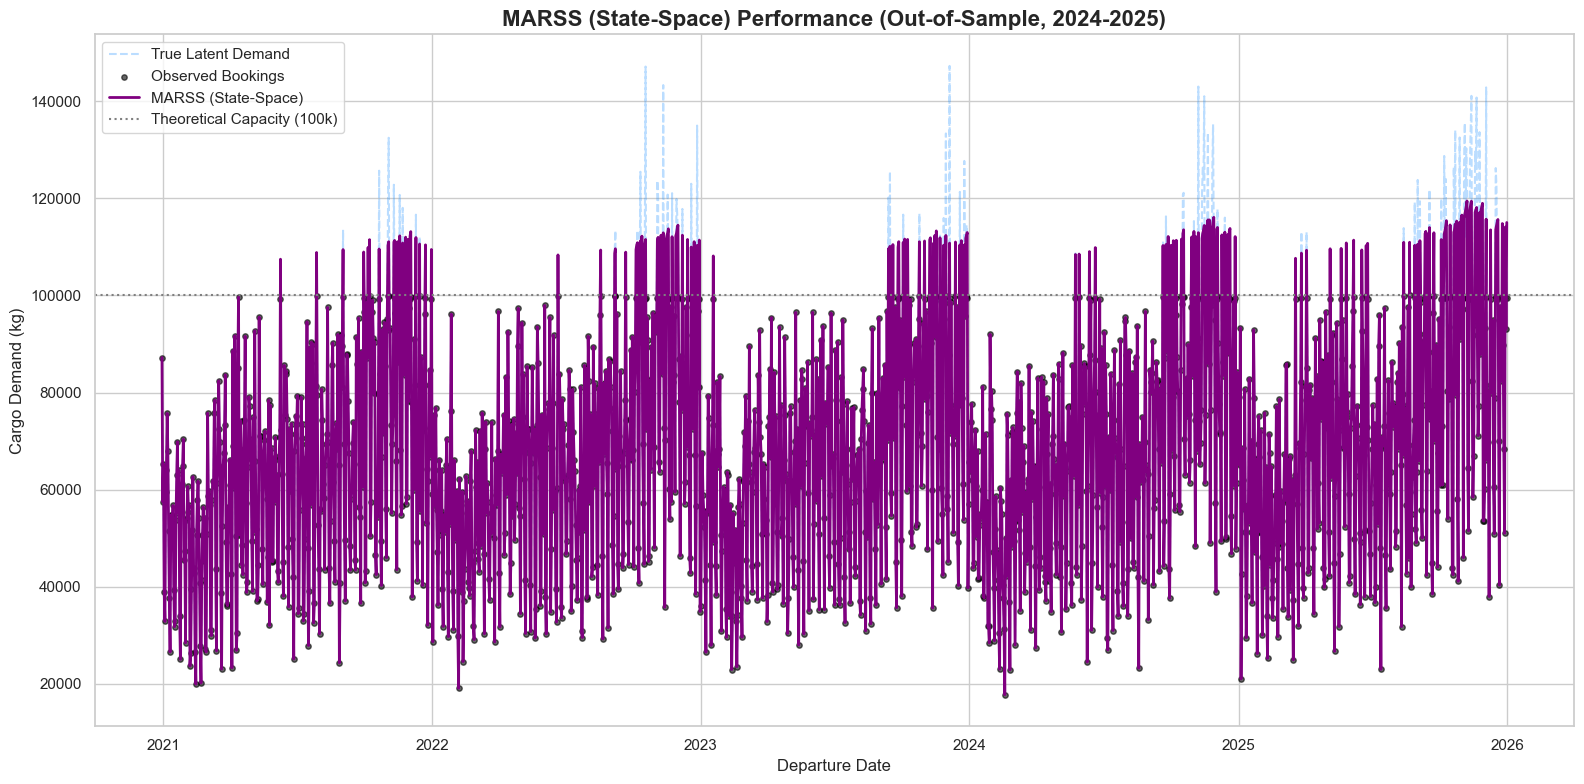

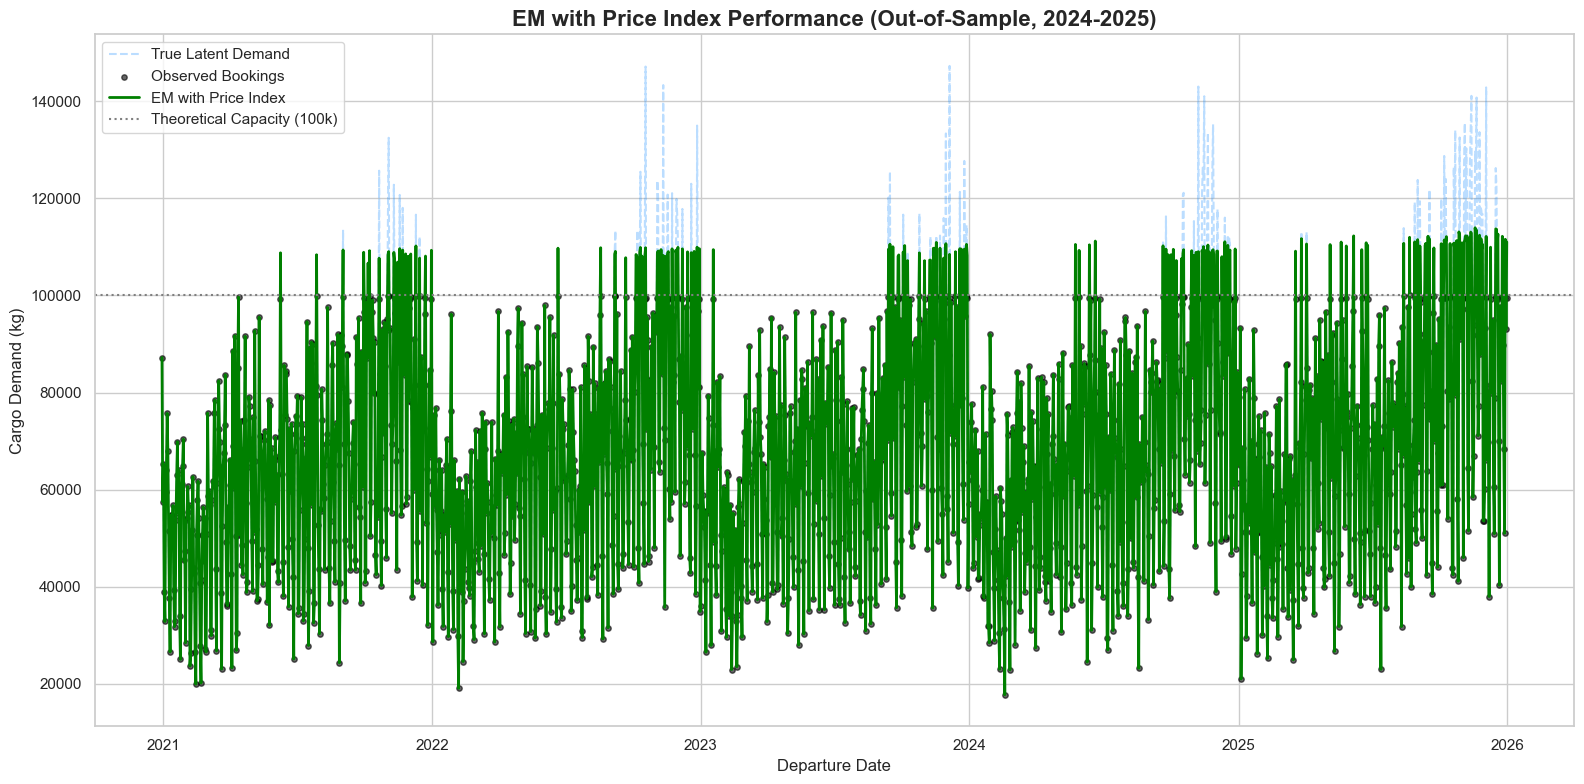

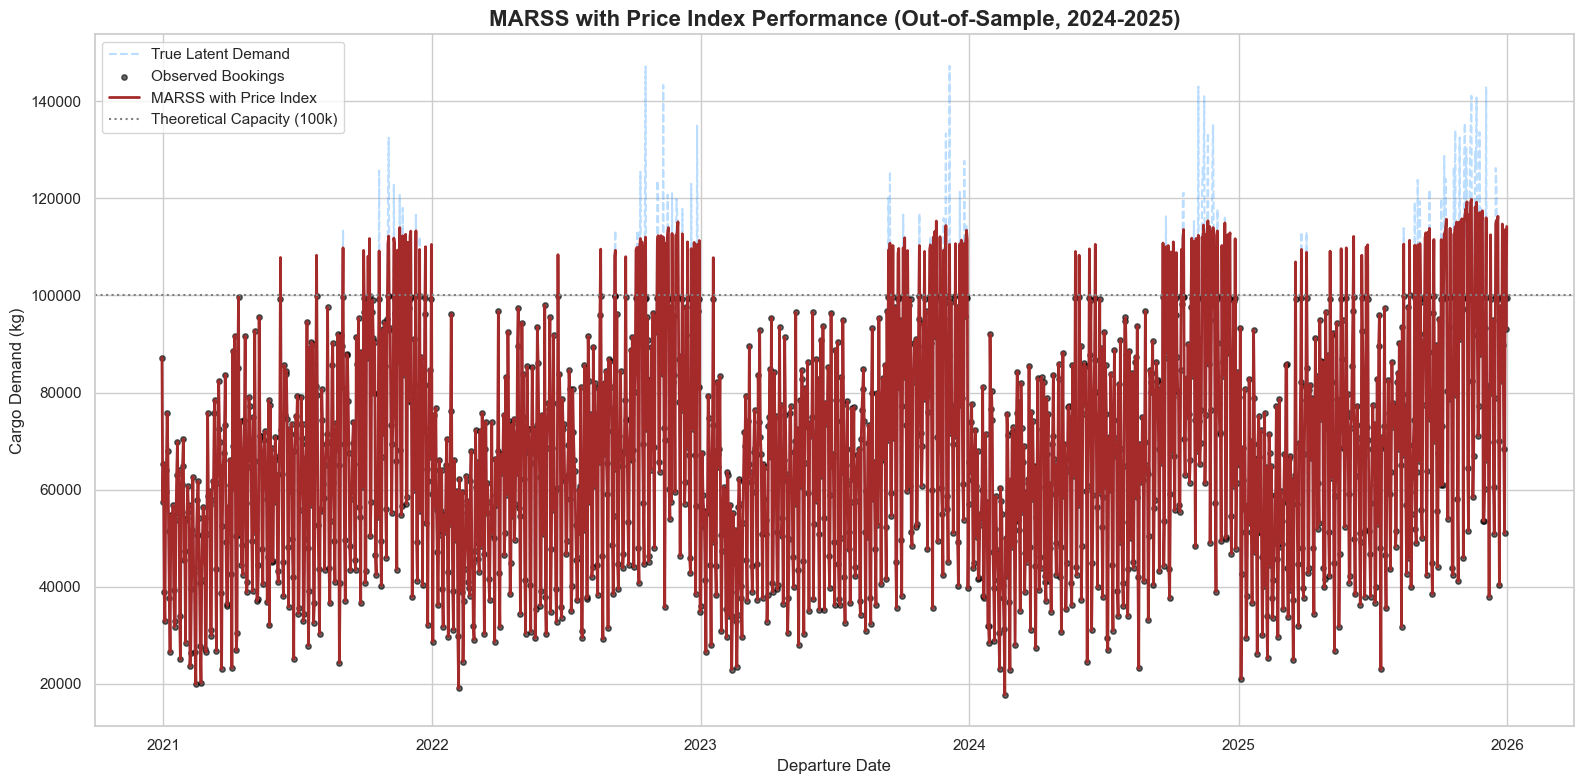

In [5]:
# Zoom in on a specific 2-year window
plot_df = eval_df[
    (eval_df['Date'].dt.year >= 2019) & 
    (eval_df['Date'].dt.year <= 2025)
]

# Common plotting function
def plot_model(model_col, model_name, model_color):
    plt.figure(figsize=(16, 8))
    
    # Ground truth & observations
    plt.plot(
        plot_df['Date'],
        plot_df['Final_True_Demand'],
        label='True Latent Demand',
        color='dodgerblue',
        alpha=0.3,
        linestyle='--'
    )
    
    plt.scatter(
        plot_df['Date'],
        plot_df['Final_Constrained_Bookings'],
        label='Observed Bookings',
        color='black',
        s=15,
        alpha=0.6
    )
    
    # Selected model
    plt.plot(
        plot_df['Date'],
        plot_df[model_col],
        label=model_name,
        color=model_color,
        linewidth=2
    )
    
    # Capacity line
    plt.axhline(
        y=100000,
        color='gray',
        linestyle=':',
        label='Theoretical Capacity (100k)'
    )
    
    plt.title(
        f'{model_name} Performance (Out-of-Sample, 2024-2025)',
        fontsize=16,
        fontweight='bold'
    )
    plt.ylabel('Cargo Demand (kg)', fontsize=12)
    plt.xlabel('Departure Date', fontsize=12)
    plt.legend(loc='upper left', fontsize=11)
    plt.tight_layout()
    plt.show()


# Plot each model separately
plot_model('Naive_Est', 'Naive (No Lift)', 'red')
plot_model('EM_Est', 'Standard EM (1-Yr Window)', 'orange')
plot_model('MARSS_Est', 'MARSS (State-Space)', 'purple')
plot_model('EMXPrice_Est', 'EM with Price Index', 'green')
plot_model('MARSSXPrice_Est', 'MARSS with Price Index', 'brown')